## Кластеризация (k-means)

Ниже реализована кластеризация методом k-means на 6 кластеров и оценка качества через коэффициент силуэта. Compound — специально «неудобный» набор: точки образуют вложенные фигуры, поэтому на нём хорошо видно ограничения k-means.


In [1]:
!pip install -q gdown
import gdown

FILE_ID = "1WeFeYg5-pnUIvLisbeNmrRnEq8rekDhS"   # Compound.txt
file_path = "/content/Compound.txt"
gdown.download(id=FILE_ID, output=file_path, quiet=False)
print("Файл сохранён в:", file_path)


Downloading...
From: https://drive.google.com/uc?id=1WeFeYg5-pnUIvLisbeNmrRnEq8rekDhS
To: /content/Compound.txt
100%|██████████| 5.43k/5.43k [00:00<00:00, 3.15MB/s]

Файл сохранён в: /content/Compound.txt


Кластерный анализ нужен для разбиения данных на группы, максимально похожиее друг на друга.
Для этого выбирается количество кластеров, на которые нужно разбить данные. Затем выбивается мера блихости объектов - та точка или тот принциа, по которому программу будет понимать, к какому кластеру отнести конкретное наблюдение.

В нашем случае будем строить анализ для 6 кластеров файла compound.txt с помощью метода k-means. Это нестандартный набор данных, так как наблюдения в файле образуют фигуры, что может стать проблемой для некоторых методов. Мы же хотим убедиться, на сколько качественно происходит кластеризация озвученным методом.

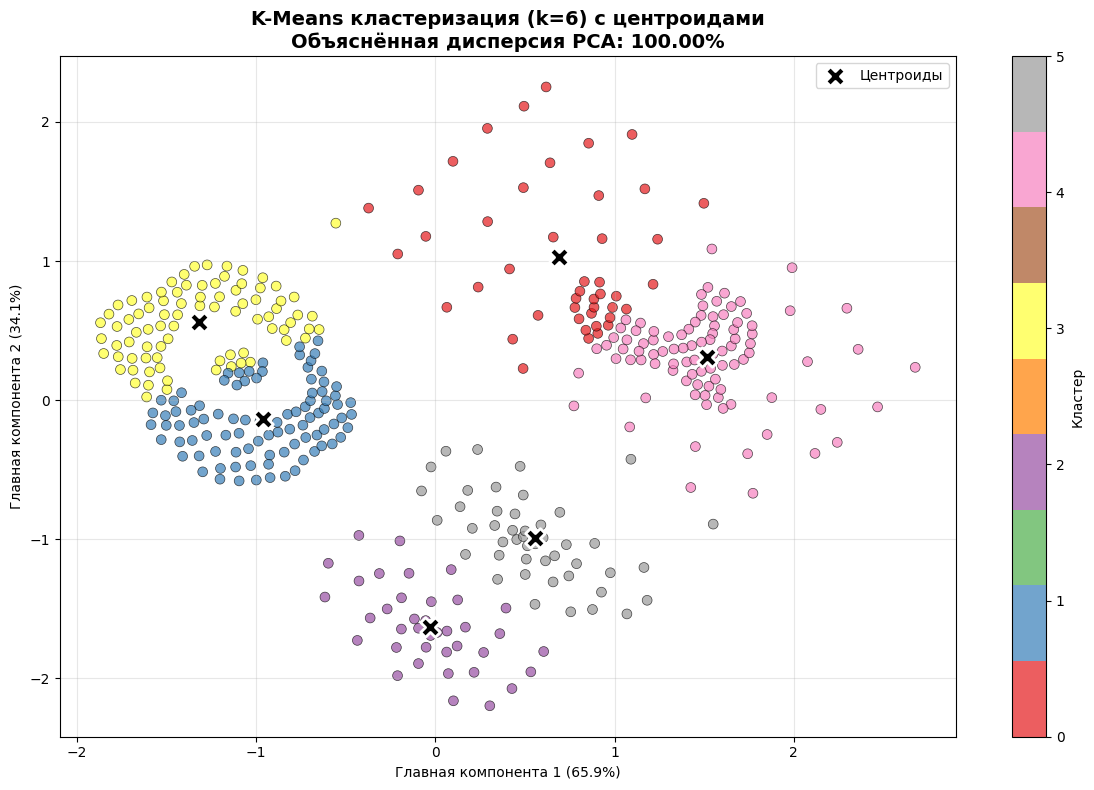

Распределение по кластерам:
0    45
1    92
2    39
3    83
4    94
5    46
Name: count, dtype: int64

Координаты центроидов в исходном пространстве:
Кластер 0: [ 1.214 -0.24 ]
Кластер 1: [-0.775 -0.581]
Кластер 2: [-1.173  1.131]
Кластер 3: [-0.536 -1.328]
Кластер 4: [1.289 0.852]
Кластер 5: [-0.309  1.093]


In [2]:
# ЗАДАЧА: разбить наблюдения на группы (кластеры) методом k-means.
# Порядок действий: загрузка -> отделение меток (если есть) -> стандартизация ->
# кластеризация на k=6 -> снижение размерности до 2D через PCA только для рисунка ->
# визуализация кластеров и их центров (центроидов).
# StandardScaler приводит признаки к одному масштабу (среднее 0, разброс 1), иначе
# признак с большими числами перетянул бы расчёт расстояний на себя.
# PCA нужен ТОЛЬКО чтобы показать многомерные данные на плоскости; на саму
# кластеризацию он не влияет.

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Путь к файлу ---
file_path = "/content/Compound.txt"

# --- 1. Загрузка данных ---
df_raw = pd.read_csv(file_path, sep=r"\s+", header=0)

# --- 2. Удаляем столбец с метками (если он есть) и оставляем только числовые признаки ---
if 'Class' in df_raw.columns:
    X = df_raw.drop(columns=['Class'])
elif 'class' in df_raw.columns:
    X = df_raw.drop(columns=['class'])
elif 'Cluster' in df_raw.columns:
    X = df_raw.drop(columns=['Cluster'])
elif 'Label' in df_raw.columns:
    X = df_raw.drop(columns=['Label'])
else:
    X = df_raw.copy()

# Оставляем только числовые столбцы
X = X.select_dtypes(include=[np.number])

# --- 3. Нормализация ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. K-Means (k=6) ---
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# --- 5. Получаем центроиды и масштабируем их обратно для визуализации ---
centroids = kmeans.cluster_centers_

# --- 6. PCA для визуализации в 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(centroids)

# --- 7. График кластеров с центроидами ---
plt.figure(figsize=(12, 8))

# Рисуем точки кластеров
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='Set1', s=50,
                      alpha=0.7, edgecolors='black', linewidth=0.5)

# Рисуем центроиды
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', s=200, marker='X',
            edgecolors='white', linewidth=2,
            label='Центроиды', zorder=5)

# Подписываем центроиды номерами кластеров
for i, (x, y) in enumerate(centroids_pca):
    plt.annotate(str(i), (x, y), fontsize=12, fontweight='bold',
                 ha='center', va='center', color='white')

# --- 8. Оформление ---
explained_var = pca.explained_variance_ratio_
plt.title(f'K-Means кластеризация (k=6) с центроидами\nОбъяснённая дисперсия PCA: {sum(explained_var):.2%}',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Главная компонента 1 ({explained_var[0]:.1%})')
plt.ylabel(f'Главная компонента 2 ({explained_var[1]:.1%})')
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 9. Вывод информации ---
print(f"Распределение по кластерам:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print(f"\nКоординаты центроидов в исходном пространстве:")
for i, cent in enumerate(centroids):
    print(f"Кластер {i}: {np.round(cent, 3)}")

Как работает k-means
Он использует Евклидово расстояние, то есть считает расстояние между центроидами в системе координат через теорему Пифагора.
Центр кластера - среднее арифметическое значение наблюдений в кластере.

Далее метод:
1. Выбирает случайные центроиды по какому либо правилу (например, максимальное расстояние от других центроидов);
2. Наблюдения относятся к тому кластеру, к чьему центроиду они ближе;
3. Центроид пересчитывается, стремясь к локальному минимуму, относя всё больше точек к своему кластеру.

После построения графика с кластерами мы строим силуэты. Силуэты показывают, на сколько плотно наблюдения сгруппировались вокруг центра каждого кластера.

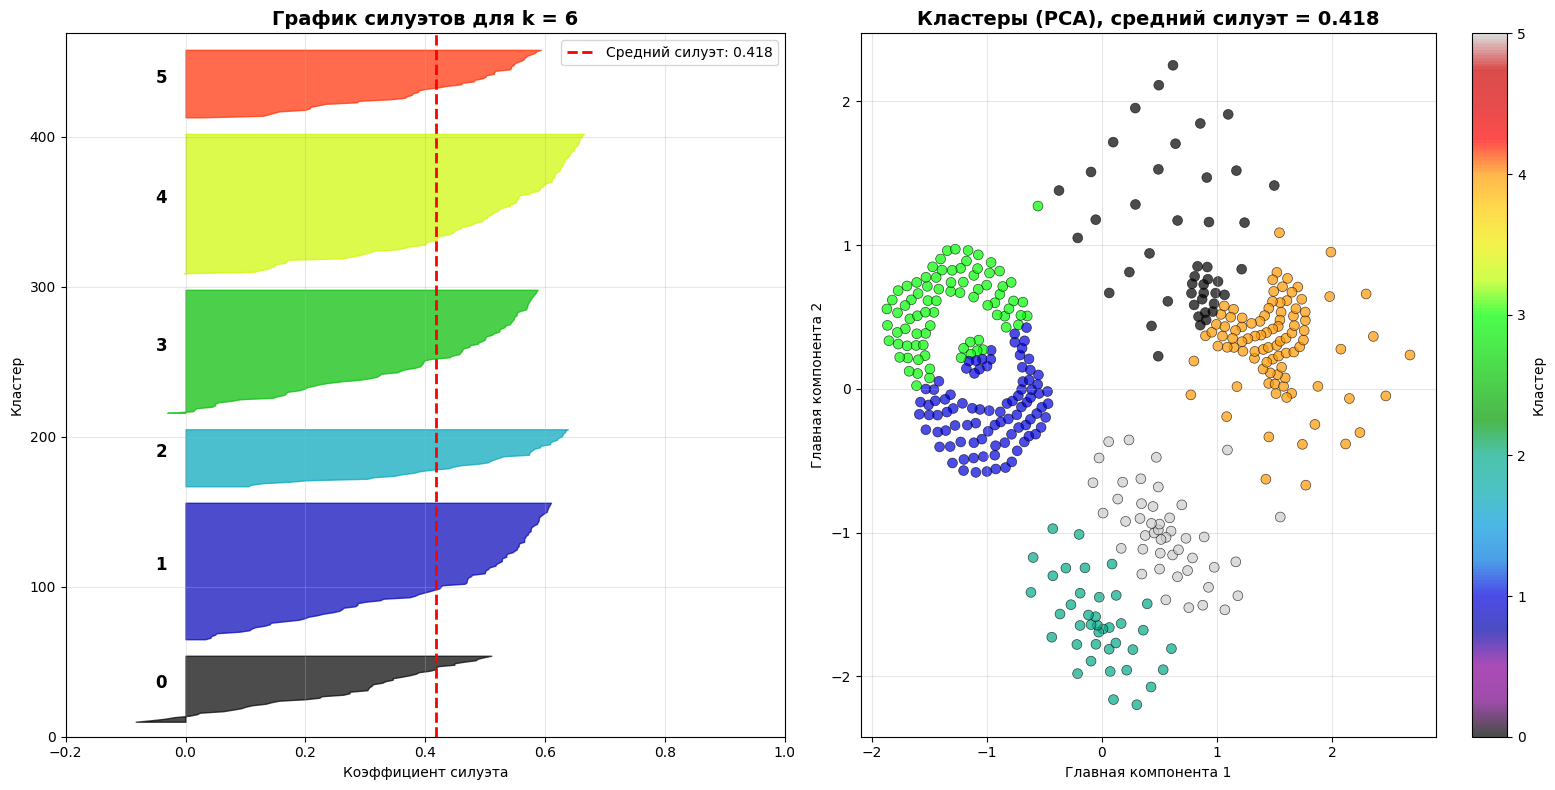

ИНТЕРПРЕТАЦИЯ ГРАФИКА СИЛУЭТОВ (k = 6)

Общий средний коэффициент силуэта: 0.4185
   (диапазон: от -1 до 1)
   УДОВЛЕТВОРИТЕЛЬНЫЙ результат: слабая структура

Анализ по каждому кластеру:

   Кластер 0:
      - Размер: 45 точек
      - Средний силуэт: 0.2578
      - Стандартное отклонение: 0.1685
      Слабый кластер — возможно, перекрывается с другими

   Кластер 1:
      - Размер: 92 точек
      - Средний силуэт: 0.4239
      - Стандартное отклонение: 0.1764
      Умеренно хороший кластер

   Кластер 2:
      - Размер: 39 точек
      - Средний силуэт: 0.4759
      - Стандартное отклонение: 0.1597
      Умеренно хороший кластер

   Кластер 3:
      - Размер: 83 точек
      - Средний силуэт: 0.3910
      - Стандартное отклонение: 0.1815
      Умеренно хороший кластер

   Кластер 4:
      - Размер: 94 точек
      - Средний силуэт: 0.4941
      - Стандартное отклонение: 0.1624
      Умеренно хороший кластер

   Кластер 5:
      - Размер: 46 точек
      - Средний силуэт: 0.4114
      - Ста

In [3]:
# ОЦЕНКА КАЧЕСТВА кластеризации через коэффициент силуэта.
# Силуэт объекта лежит в диапазоне от -1 до 1:
#   близко к 1  - объект уверенно внутри своего кластера;
#   около 0     - объект на границе между кластерами;
#   меньше 0    - объект, возможно, попал не в тот кластер.
# Средний силуэт по всем объектам - общая оценка качества разбиения.
# Слева рисуем силуэтные полосы по кластерам, справа - те же точки в 2D (PCA).

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Путь к файлу ---
file_path = "/content/Compound.txt"

# --- 1. Загрузка данных ---
df_raw = pd.read_csv(file_path, sep=r"\s+", header=0)

# --- 2. Удаляем столбец с метками (если он есть) ---
if 'Class' in df_raw.columns:
    X = df_raw.drop(columns=['Class'])
elif 'class' in df_raw.columns:
    X = df_raw.drop(columns=['class'])
elif 'Cluster' in df_raw.columns:
    X = df_raw.drop(columns=['Cluster'])
elif 'Label' in df_raw.columns:
    X = df_raw.drop(columns=['Label'])
else:
    X = df_raw.copy()

# Оставляем только числовые столбцы
X = X.select_dtypes(include=[np.number])

# --- 3. Нормализация ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. Параметры ---
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# --- 5. Расчёт силуэтов ---
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

# --- 6. Построение графика силуэтов ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ========== Левый график: силуэты ==========
ax1.set_xlim([-0.2, 1])
ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

y_lower = 10
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

for i in range(n_clusters):
    # Силуэтные значения для кластера i
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Закрашиваем область
    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Подпись кластера
    ax1.text(-0.05, y_lower + size_cluster_i / 2., str(i), fontsize=12, fontweight='bold')

    y_lower = y_upper + 10

# Вертикальная линия среднего силуэта
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2,
            label=f'Средний силуэт: {silhouette_avg:.3f}')

ax1.set_title(f'График силуэтов для k = {n_clusters}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Коэффициент силуэта')
ax1.set_ylabel('Кластер')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# ========== Правый график: точки в 2D ==========
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='nipy_spectral',
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
ax2.set_title(f'Кластеры (PCA), средний силуэт = {silhouette_avg:.3f}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Главная компонента 1')
ax2.set_ylabel('Главная компонента 2')
plt.colorbar(scatter, ax=ax2, label='Кластер')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 7. Детальная интерпретация ---
print("=" * 70)
print(f"ИНТЕРПРЕТАЦИЯ ГРАФИКА СИЛУЭТОВ (k = {n_clusters})")
print("=" * 70)

print(f"\nОбщий средний коэффициент силуэта: {silhouette_avg:.4f}")
print(f"   (диапазон: от -1 до 1)")

# Оценка качества
if silhouette_avg > 0.5:
    print("   ХОРОШИЙ результат: структура кластеров чёткая")
elif silhouette_avg > 0.25:
    print("   УДОВЛЕТВОРИТЕЛЬНЫЙ результат: слабая структура")
else:
    print("   ПЛОХОЙ результат: данные не подходят для кластеризации")

print("\nАнализ по каждому кластеру:")
for i in range(n_clusters):
    cluster_vals = sample_silhouette_values[cluster_labels == i]
    mean_val = np.mean(cluster_vals)
    std_val = np.std(cluster_vals)

    print(f"\n   Кластер {i}:")
    print(f"      - Размер: {len(cluster_vals)} точек")
    print(f"      - Средний силуэт: {mean_val:.4f}")
    print(f"      - Стандартное отклонение: {std_val:.4f}")

    if mean_val > 0.5:
        print(f"      Компактный и хорошо отделённый кластер")
    elif mean_val > 0.3:
        print(f"      Умеренно хороший кластер")
    elif mean_val > 0:
        print(f"      Слабый кластер — возможно, перекрывается с другими")
    else:
        print(f"      Очень плохой кластер — точки могли быть отнесены не туда")

print("\nКак читать левый график:")
print("   • Толщина 'лепестка' = размер кластера")
print("   • Ширина лепестка = коэффициент силуэта (чем шире, тем лучше)")
print("   • Если лепесток выходит за красную пунктирную линию — кластер хороший")
print("   • Если лепесток узкий или заходит в отрицательную область — кластер плохой")
print("   • Если все лепестки примерно одинаковы и широкие — идеальная кластеризация")

# Определение оптимального k через силуэт (опционально)
print("\nРекомендация:")
if silhouette_avg < 0.3:
    print("   Попробуйте другое значение k или другой метод кластеризации (DBSCAN, Agglomerative)")
elif n_clusters > 2 and silhouette_avg > 0.5:
    print("   Текущее k = 6 подходит хорошо. Можно попробовать увеличить/уменьшить k для сравнения")
else:
    print("   Результат приемлемый, но возможны улучшения при изменении k")

По силуэтам оценивается качество кластеризации. Силуэт графически показывает, насколько плотно точки сгруппировались
вокруг центра каждого кластера.

Чем ближе точки к центру кластера, тем более выпуклым будет низ фигуры, приближаясь к уровню самой первой точки - центра.

Среднее силуэта показывает, на сколько хорошо объекты разделены на кластеры и на сколько похожи на объекты внутри своего кластера по сравнению с другими.

K-means справился плохо. Метод предполагает, что кластеры выпуклые и сферические и разбивает пространство на линейно разделимые области.
Файл содержит кластеры сложной формы - фигуры.
Поэтому k-means не может восстановить истинную структуру.

Мешающие ограничения: метод работает только с шарообразными клсатерами, у нас есть кольца; не работает с нелинейными структурами; чувствителен к выбросам и масштабу

Недостатки k-means
1. Нужно задавать число кластеров k.
2. Метод сходится к локальным минимумам. K-means минимизирует сумму квадратов расстояний до центров кластеров, но эта функция имеет множество локальных минимумов. В результате алгоритм гарантированно находит один из ближайших локальных минимумов, а не глобально оптимальное решение, что может дать далекий от идеала результат.
3. Метод опирается на гипотезу о компактности – «сферические
сгустки». Алгоритм предполагает, что кластеры имеют сферическую (шарообразную) форму и примерно одинаковый размер и плотность. Если данные образуют вытянутые, изогнутые, вложенные или другие сложные формы (например, «полумесяцы»), k-means с ними справляется крайне плохо, разрывая естественные структуры. А у нас именно такие.
4. Метод крайне чувствителен к начальной конфигурации
(начальные центры кластеров), к выбросам.
5. Хорошо работает только с непрерывными данными.
